In [26]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

In [54]:
hdul = fits.open('AL1_SOLEXS_20260624_SDD2_L1.lc.gz')

gtif = fits.open('AL1_SOLEXS_20260624_SDD2_L1.gti.gz')

pif = fits.open('AL1_SOLEXS_20260624_SDD2_L1.pi.gz')
pif.info()

Filename: AL1_SOLEXS_20260624_SDD2_L1.pi.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      22   ()      
  1  SPECTRUM      1 BinTableHDU     44   86400R x 6C   [D, D, J, 340K, 340D, D]   


In [64]:
lc_data = hdul['RATE'].data

gti_data = gtif['GTI'].data

pi_data = pif['SPECTRUM'].data
gti_data

FITS_rec([(1.78225920e+09, 1.78225920e+09),
          (1.78225921e+09, 1.78228195e+09),
          (1.78228196e+09, 1.78233636e+09),
          (1.78233636e+09, 1.78234560e+09)],
         dtype=(numpy.record, [('START', '>f8'), ('STOP', '>f8')]))

In [65]:
# LC file
time = np.array(lc_data['TIME'])
counts = np.array(lc_data['COUNTS'])
slope = (np.diff(counts) / np.diff(time))

# GTI file
start = np.array(gti_data['START'])
stop = np.array(gti_data['STOP'])

# cleaning the LC file
is_good = np.zeros(len(time), dtype=bool)
for i in range(len(start)):
    # Mark as 'True' if the time is within this specific window
    condition = (time >= start[i]) & (time <= stop[i])
    is_good = is_good | condition
counts[~is_good] = 0

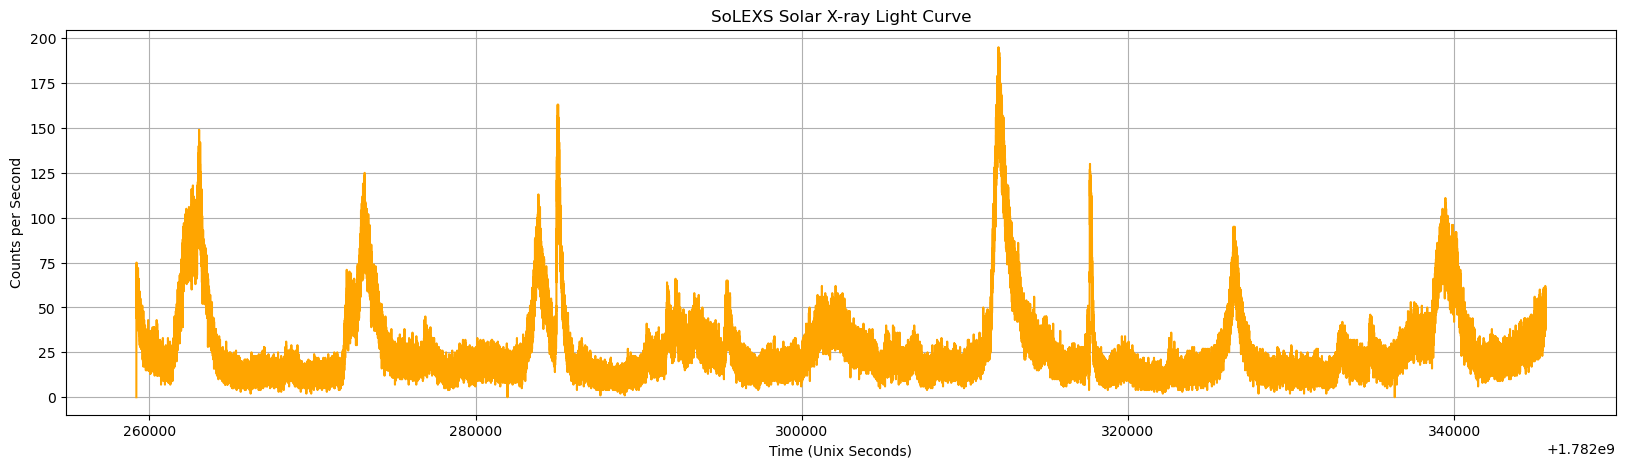

In [66]:
# how to plot the light curve and the slope of the light curve in the same plot
plt.figure(figsize=(20, 5))
plt.plot(time, counts, label='Counts', color='Orange')
plt.xlabel('Time (Unix Seconds)')
plt.ylabel('Counts per Second')
plt.title('SoLEXS Solar X-ray Light Curve')
plt.grid(True)
plt.show()